<a href="https://colab.research.google.com/github/davidmkidd/UK-Supermarket-Carbon-Emissions/blob/main/UKSmktComp_Emissions_Scope1and2_Market.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://evoviz.uk/wp-content/uploads/2026/04/Food_Divider_trans2.png">

# Scope 1 and 2 Market-based
$C_{s12, market} = C_{s1} + C_{s2, market}$

Market-based metrics are usually only applied to Scope 2 purchased energy, but may also be applied to owned direct energy sources, e.g. heat from biogas.

'Scope 1 and 2 market-based emissions' are therefore the sum of location-based Scope 1 and market-based Scope 2 emissions.

It is a measure the overall carbon emissions a retailer produces from its direct operations based on the intensity of the purchased source.


# Set up



In [ ]:
# Load libraries
library(dplyr)   # Data manipulation
library(ggplot2) # Graphing
library(repr)    # Graph size
options(repr.plot.width = 10, repr.plot.height = 8)
library(broom)   # Format model output
library(knitr)    # Format model output

# Download cleaned and summarised emmissions data
url <- "https://raw.githubusercontent.com/davidmkidd/UK-Supermarket-Carbon-Emissions/refs/heads/main/retailer_emissions_yr.csv"
download_path <- "/content/retailer_emissions_yr.csv"
download.file(url, destfile = download_path, mode = "wb")
#Import
emissions.yr <- read.csv("/content/retailer_emissions_yr.csv", header=TRUE, stringsAsFactors=FALSE)

# Download retailer data
url <- "https://raw.githubusercontent.com/davidmkidd/UK-Supermarket-Carbon-Emissions/refs/heads/main/retailer_data.csv"
download_path <- "/content/retailer_data.csv"
download.file(url, destfile = download_path, mode = "wb")
#Import
retailer.data <- read.csv("/content/retailer_data.csv", header=TRUE, stringsAsFactors=FALSE)

# Make palette list
retailer.pal <- setNames(retailer.data$hex, retailer.data$retailer_code)
# Make code/name list
retailer.code <- setNames(retailer.data$retailer, retailer.data$retailer_code)

# Truncate year to 1s and 10s
emissions.yr$year2 <- emissions.yr$year - 2000

# Split reported absolute and intenstity values into seperate data frames as they will will be used differenty.

# Reported Absolute Values
emissions.yr.absolute <- emissions.yr %>%
   filter(kpi_type == "Measure")
nrow(emissions.yr.absolute)

# Reported Intensity Values
emissions.yr.intensity <- emissions.yr %>%
   filter(kpi_type == "Intensity")
nrow(emissions.yr.intensity)

[1] 592

[1] 181

# Absolute Emissions

In [ ]:
# Market-based Scope 1 and 2
data.abs <- emissions.yr.absolute %>%
  filter(kpi == "Scope 1 and 2" & method == "Market")
nrow(data.abs)

[1] 78

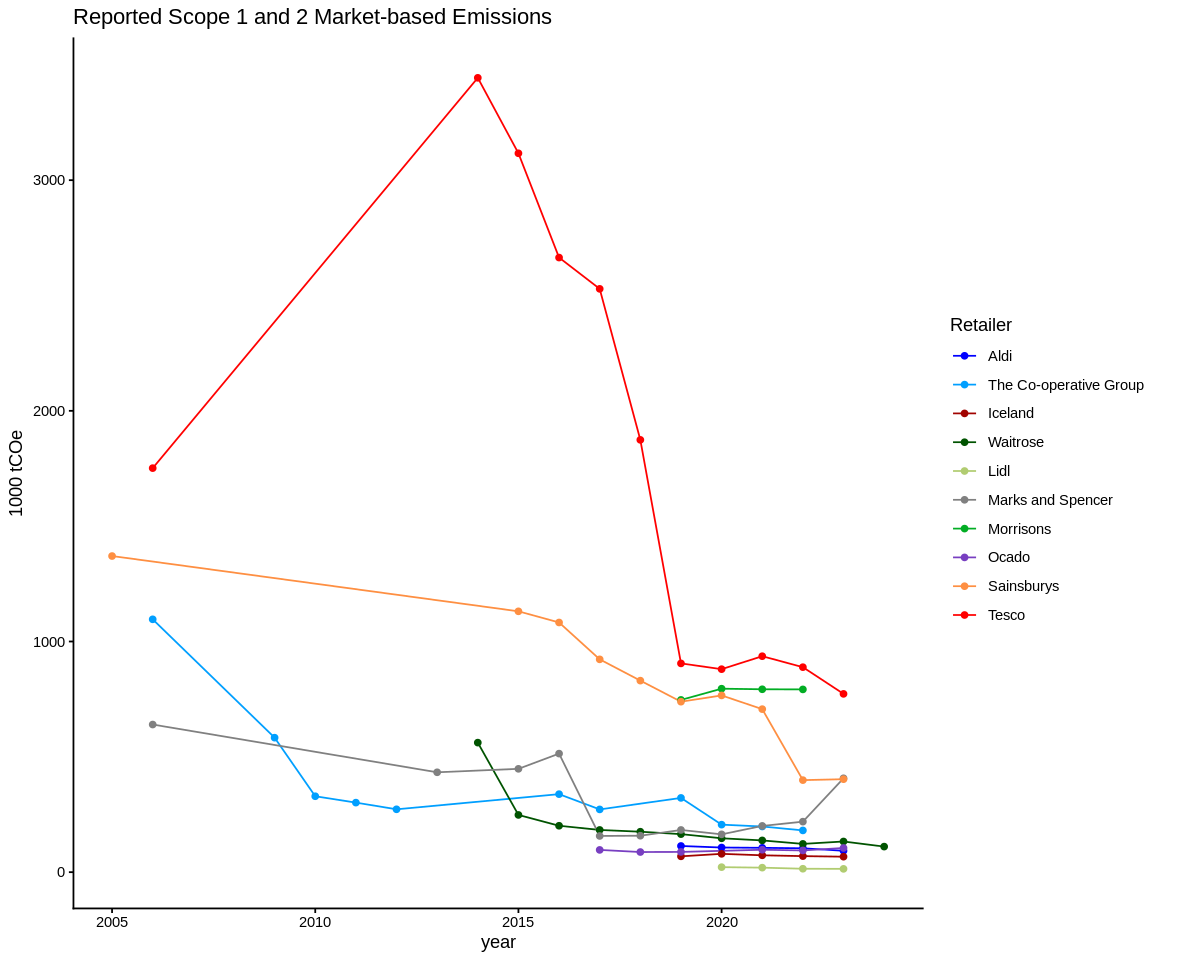

In [ ]:
# Plot absolute values
ggplot(data.abs, aes(x = year, y = value/1000, colour = retailer_code)) +
  geom_line(na.rm = TRUE)  +
  geom_point(na.rm = TRUE) +
  ggtitle("Reported Scope 1 and 2 Market-based Emissions") +
  ylab("1000 tCOe") +
  scale_colour_manual(name = "Retailer", values = retailer.pal, labels = retailer.code) +
  theme_classic()


Taking the supplier of purchased energy into account reveals.

* Lidl, Iceland, and Aldi still have the lowest Scope 1 and 2 intensity footprints.
* Tesco had the greatest intensity until 2019 when it joined the pack.
* Morrisons now has the highest intensity.
* Reported intensity is lower for the three retailers with data.
* Since 2020, improvement has almost flatlined.

Scope 1 and 2 market-based emissions are the sum of Scope 1 location-based emissions that is strongly linearly with total store area, and Scope-2 market-based emissions that do not scale with retailer size.

A weaker linear relationship is expected for Scope 1 and 2 market-based emissions.

## Store Number

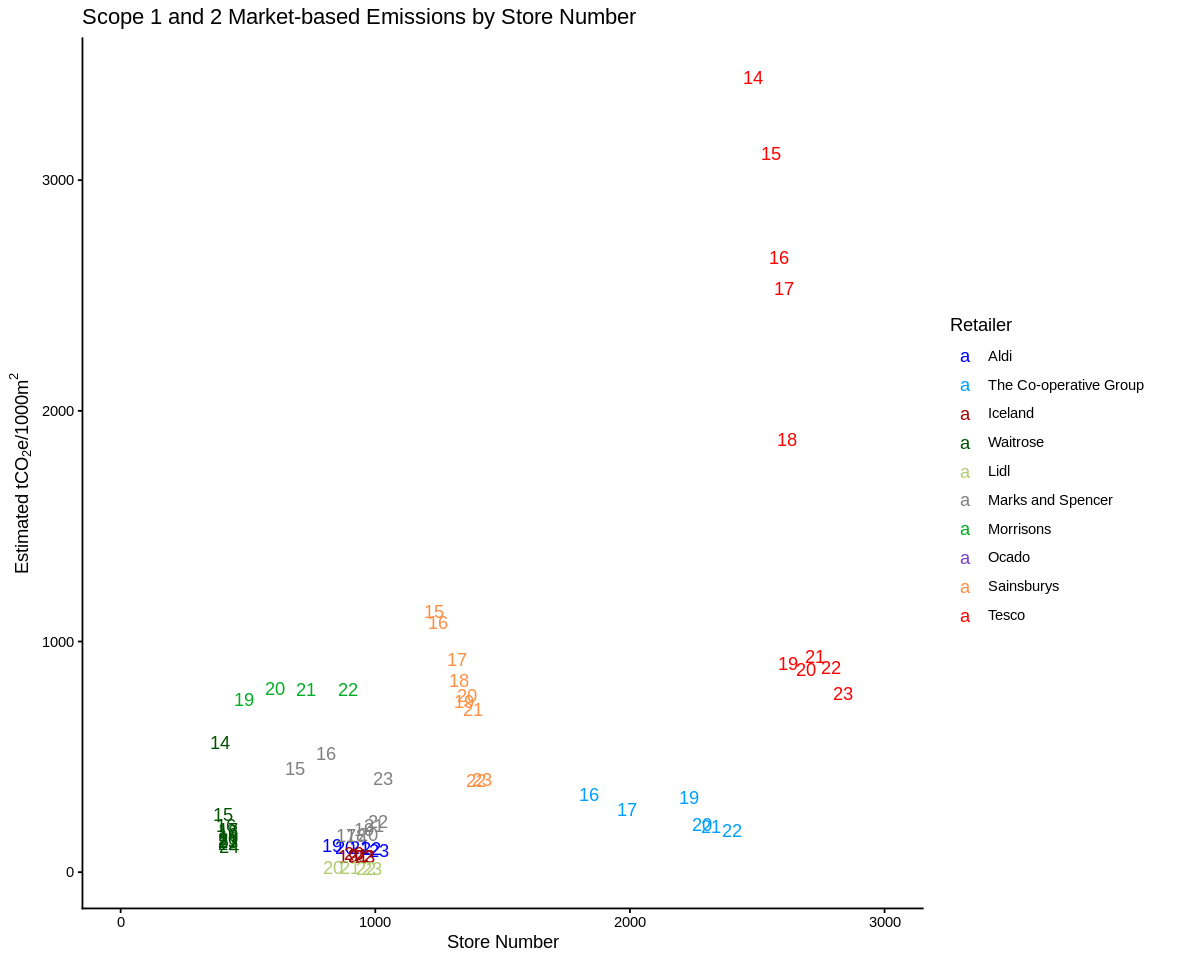

In [ ]:
ggplot(data.abs, aes(x = total_store, y = value/1000, colour = retailer_code, labels = year2)) +
  geom_text(na.rm = TRUE) +
  ggtitle("Scope 1 and 2 Market-based Emissions by Store Number") +
  xlab("Store Number") +
  ylab(expression(paste("Estimated tCO"[2],"e/1000m"^2))) +
  scale_colour_manual(name = "Retailer", values = retailer.pal, labels = retailer.code) +
  scale_x_continuous(limits = c(0, 3000), breaks=seq(0, 3) * 1000) +
  theme_classic()

## Store Area

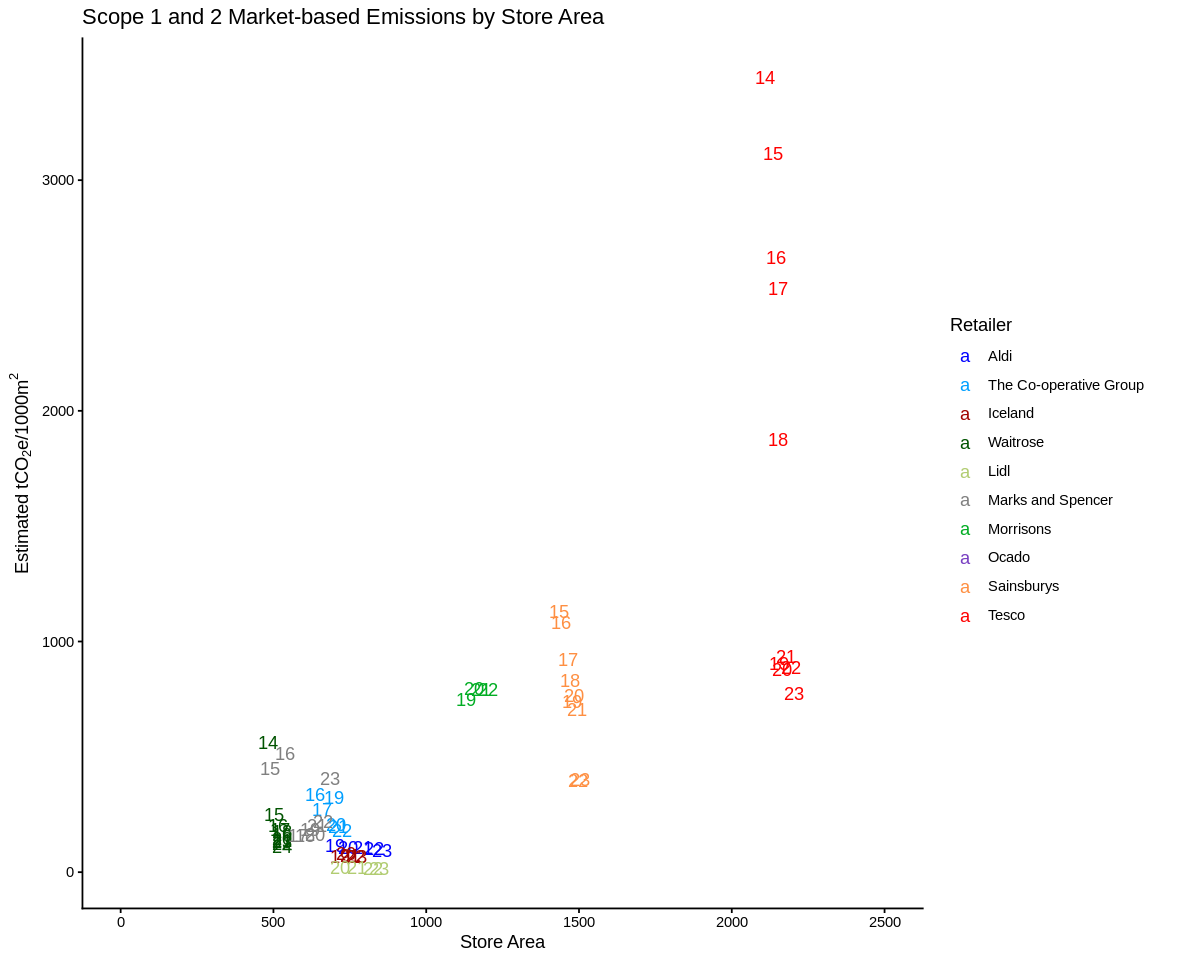

In [ ]:
ggplot(data.abs, aes(x = total_area/1000, y = value/1000, colour = retailer_code, labels = year2)) +
  geom_text(na.rm = TRUE) +
  ggtitle("Scope 1 and 2 Market-based Emissions by Store Area") +
  xlab("Store Area") +
  ylab(expression(paste("Estimated tCO"[2],"e/1000m"^2))) +
  scale_colour_manual(name = "Retailer", values = retailer.pal, labels = retailer.code) +
  scale_x_continuous(limits = c(0, 2500)) +
  theme_classic()

In [ ]:
# Calculate mean emissions for years 2020 - 2022
data.abs.mean <- data.abs %>%
  filter(year >= 2020 & year <= 2022) %>%
  group_by(retailer_code) %>%
  summarise_at(vars(value, total_store, total_area),list(mean = mean))

In [ ]:
# Scope 2 location ~ Store Number
lm_model <- lm(data = data.abs.mean, value_mean ~ total_store_mean, na.action=na.omit)
glance(lm_model) %>%
  kable(digits = 3)
tidy(lm_model) %>%
  kable(digits = 3)
paste("")

In [ ]:
# Scope 2 location ~ Store Area
lm_model <- lm(data = data.abs.mean, value_mean ~ total_area_mean, na.action=na.omit)
glance(lm_model) %>%
  kable(digits = 3)
tidy(lm_model) %>%
  kable(digits = 3)
paste("")

## Store Number and Area

In [ ]:
# Scope 2 location ~ Store Number + Area
lm_model <- lm(data = data.abs.mean, value_mean ~ total_store_mean + total_area_mean, na.action=na.omit)

glance(lm_model) %>%
  kable(digits = 3)
tidy(lm_model) %>%
  kable(digits = 3)
paste("")

[1] "Store Number"



| r.squared| adj.r.squared|    sigma| statistic| p.value| df|   logLik|     AIC|     BIC|     deviance| df.residual| nobs|
|---------:|-------------:|--------:|---------:|-------:|--:|--------:|-------:|-------:|------------:|-----------:|----:|
|     0.214|         0.102| 320489.7|     1.906|    0.21|  1| -125.738| 257.476| 258.068| 718995468405|           7|    9|



|term             |  estimate|  std.error| statistic| p.value|
|:----------------|---------:|----------:|---------:|-------:|
|(Intercept)      | 80996.121| 214673.701|     0.377|   0.717|
|total_store_mean |   203.429|    147.357|     1.381|   0.210|

[1] ""

[1] "Store Area"

...

[1] ""

[1] "Store Number and Area"



| r.squared| adj.r.squared|    sigma| statistic| p.value| df|   logLik|     AIC|     BIC|     deviance| df.residual| nobs|
|---------:|-------------:|--------:|---------:|-------:|--:|--------:|-------:|-------:|------------:|-----------:|----:|
|     0.793|         0.724| 177539.5|     11.51|   0.009|  2| -119.728| 247.457| 248.246| 189121724179|           6|    9|



|term             |    estimate|  std.error| statistic| p.value|
|:----------------|-----------:|----------:|---------:|-------:|
|(Intercept)      | -198855.950| 137117.097|    -1.450|   0.197|
|total_store_mean |     -83.071|    107.454|    -0.773|   0.469|
|total_area_mean  |       0.639|      0.156|     4.100|   0.006|

[1] ""

## Best Model

* Store number is insignificant.

* Store area predicts 77% of emissions with *p* = 0.002.

* Both variables explain the most variation (79%), but store number is insignificant (p = 0.135).

The best model is:  $C{scope12, market} \sim StoreArea$

In [ ]:
# Calculate estimated intensity for absolute values
data.abs$intensity <- data.abs$value/data.abs$total_area

# Intensity

In [ ]:
# Estimated and Reported Scope 2 market-based intensity
data.int <- emissions.yr.intensity %>%
  filter(kpi == "Scope 1 and 2" & method == "Market" & unit_denom_1 == "m2")
nrow(data.int)

[1] 13

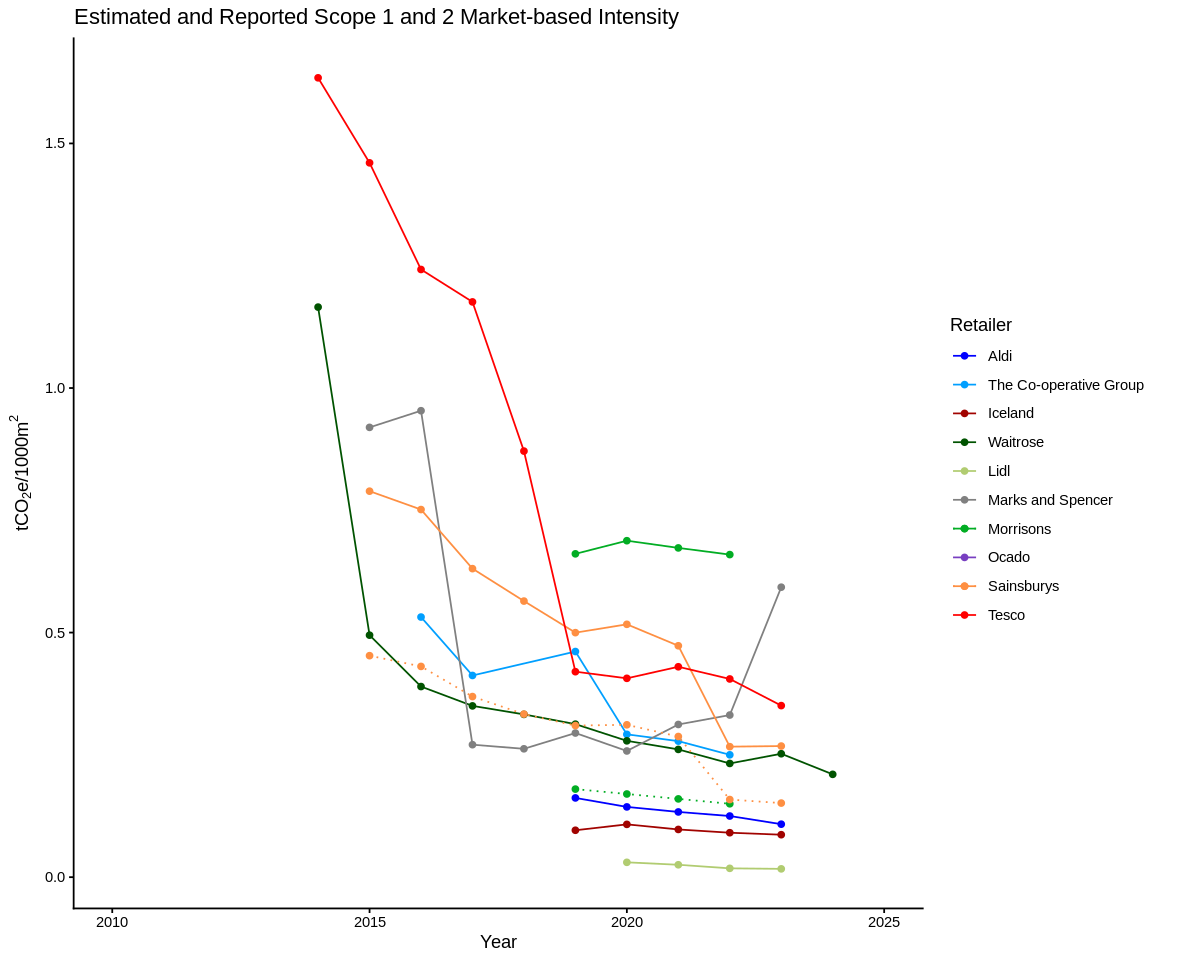

In [ ]:

ggplot(data.abs, aes(x = year, y = intensity, colour = retailer_code)) +
  geom_line(na.rm = TRUE)  +
  geom_point(na.rm = TRUE) +
  geom_line(data = data.int, aes(x = year, y = value), linetype="dotted", na.rm = TRUE)  +
  geom_point(data = data.int, aes(x = year, y = value), na.rm = TRUE) +
  ggtitle("Estimated and Reported Scope 1 and 2 Market-based Intensity") +
  xlab("Year") +
  ylab(expression(paste("tCO"[2],"e/1000m"^2))) +
  scale_colour_manual(name = "Retailer", values = retailer.pal, labels = retailer.code) +
  scale_x_continuous(limits = c(2010, 2025)) +
  theme_classic()

* Market-based Scope 1 and 2 intensity reveals ...

---

[Main Page](https://colab.research.google.com/drive/1f8a0pXfF9PqCujiwjf4TO4-k7ezt-6b3?usp=sharing)

[Reported and Estimated Intensity](https://colab.research.google.com/drive/1MvdMFH9blIjT7dHAddXlgNIksMtOk8IW?usp=sharing)

---

